# Evaluación de los métodos

## Carga del dataset y calculo de atributos


In [14]:
import pandas as pd
from load import load_dataset

dataset = load_dataset("futbol_uruguayo.csv")

print(dataset.head())


                   home                              away       date  gh  ga  \
0           Bella Vista                 Defensor Sporting 1932-03-05   1   2   
1            CA Penarol                       River Plate 1932-03-05   1   1   
2       Central Espanol        Rampla Juniors Futbol Club 1932-03-05   1   0   
3  Montevideo Wanderers                       Racing Club 1932-03-05   3   0   
4              Nacional  Institucion Atletica Sud America 1932-03-05   2   0   

  result  record_difference  last_matches_difference  goal_difference_value  \
0      V                0.0                      0.0                    0.0   
1      E                0.0                      0.0                    0.0   
2      L                0.0                      0.0                    0.0   
3      L                0.0                      0.0                    0.0   
4      L                0.0                      0.0                    0.0   

   attack_difference  defense_difference  dr

## División del conjunto en entrenamiento y evaluación

In [15]:
#separamos cronologicamente el conjunto de entrenamiento y el de evaluacion
#la evaluacion se mantiene separada hasta haber elegido los hiperparametros

train = dataset[
    dataset["date"] < pd.Timestamp("2024-01-01")
].copy()

test = dataset[
    (dataset["date"] >= pd.Timestamp("2024-01-01"))
    & (dataset["date"] < pd.Timestamp("2026-01-01"))
].copy()

print("Cantidad de partidos de entrenamiento:", len(train))
print("Cantidad de partidos de evaluacion:", len(test))

Cantidad de partidos de entrenamiento: 14734
Cantidad de partidos de evaluacion: 472


## Creación del pipeline

In [16]:
import sys
import os

from pipeline import create_model_pipeline, pipeline_input_attributes


# Agrega la carpeta padre (Tarea1) al path de búsqueda de Python
sys.path.append(os.path.abspath(".."))


#hacemos el arbol de decision usando solamente el conjunto de entrenamiento
from decisionTree.classifier import Classifier as DecisionTreeClassifier

treeID3 = DecisionTreeClassifier(min_info_gain=0.0065)

#dejamos fijos los mejores margenes del experimento anterior
model = create_model_pipeline(
    treeID3,
    record_margin=0.07,
    last_matches_margin=0.0,
    goal_difference_margin=0.8,
    attack_margin=0.25,
    defense_margin=0.02,
    draw_low_threshold=0.16,
    draw_high_threshold=0.38
)

In [17]:
X_train = train[pipeline_input_attributes].copy()
y_train = train["result"].copy()

X_test = test[pipeline_input_attributes].copy()
y_test = test["result"].copy()

print("Filas de entrenamiento:", len(X_train))
print("Filas reservadas para evaluacion final:", len(X_test))

Filas de entrenamiento: 14734
Filas reservadas para evaluacion final: 472


## División temporal por temporada para Cross-Validation

Se hizo esto por ... TODO: Justificar 

In [18]:
import numpy as np

#cada temporada se valida usando solamente las temporadas anteriores
# Validamos usando todo el historial moderno (desde 1950)
validation_years = list(range(1950, 2023))
train_years = train["date"].dt.year.to_numpy()
window_years = 5 # Agregamos la ventana de tiempo
temporal_splits = []

for validation_year in validation_years:
    fit_indices = np.flatnonzero(
        (train_years < validation_year) & (train_years >= validation_year - window_years)
    )
    validation_indices = np.flatnonzero(
        train_years == validation_year
    )

    temporal_splits.append((
        fit_indices,
        validation_indices
    ))

    print(
        f"Validacion {validation_year}:",
        f"entrenamiento={len(fit_indices)},",
        f"validacion={len(validation_indices)}"
    )

Validacion 1950: entrenamiento=412, validacion=93
Validacion 1951: entrenamiento=415, validacion=90
Validacion 1952: entrenamiento=415, validacion=91
Validacion 1953: entrenamiento=414, validacion=90
Validacion 1954: entrenamiento=454, validacion=90
Validacion 1955: entrenamiento=454, validacion=90
Validacion 1956: entrenamiento=451, validacion=90
Validacion 1957: entrenamiento=451, validacion=90
Validacion 1958: entrenamiento=450, validacion=90
Validacion 1959: entrenamiento=450, validacion=91
Validacion 1960: entrenamiento=451, validacion=91
Validacion 1961: entrenamiento=452, validacion=92
Validacion 1962: entrenamiento=454, validacion=90
Validacion 1963: entrenamiento=454, validacion=132
Validacion 1964: entrenamiento=496, validacion=90
Validacion 1965: entrenamiento=495, validacion=90
Validacion 1966: entrenamiento=494, validacion=90
Validacion 1967: entrenamiento=492, validacion=90
Validacion 1968: entrenamiento=492, validacion=90
Validacion 1969: entrenamiento=450, validacion=12

In [19]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

#buscamos los limites de la tendencia al empate y la ganancia minima
# Busqueda local alrededor de los ganadores registrados en el CSV.
param_grid = {
    "model__min_info_gain": [
        0.0045,
        0.005,
        0.0055,
        0.00575,
        0.006,
        0.00625,
        0.0065,
        0.00675,
        0.007,
        0.00725,
        0.0075,
        0.008,
        0.0085
    ],
    "preprocessing__differences__discretizer__attack_margin": [
        0.2,
        0.21,
        0.22,
        0.23,
        0.24,
        0.245,
        0.25,
        0.255,
        0.26,
        0.27,
        0.28,
        0.3
    ],
    "preprocessing__differences__discretizer__defense_margin": [
        0.0,
        0.005,
        0.01,
        0.0125,
        0.015,
        0.0175,
        0.02,
        0.0225,
        0.025,
        0.0275,
        0.03,
        0.035,
        0.04
    ],
    "preprocessing__differences__discretizer__goal_difference_margin": [
        0.7,
        0.725,
        0.75,
        0.775,
        0.7875,
        0.8,
        0.8125,
        0.825,
        0.85,
        0.875,
        0.9
    ],
    "preprocessing__differences__discretizer__last_matches_margin": [
        0.0,
        0.001,
        0.005,
        0.01,
        0.02,
        0.03,
        0.04,
        0.05,
        0.06,
        0.07
    ],
    "preprocessing__differences__discretizer__record_margin": [
        0.05,
        0.055,
        0.06,
        0.0625,
        0.065,
        0.0675,
        0.07,
        0.0725,
        0.075,
        0.0775,
        0.08,
        0.085
    ],
    "preprocessing__draw_rate__discretizer__high_threshold": [
        0.35,
        0.36,
        0.37,
        0.375,
        0.3775,
        0.38,
        0.3825,
        0.385,
        0.39,
        0.395,
        0.4,
        0.41
    ],
    "preprocessing__draw_rate__discretizer__low_threshold": [
        0.14,
        0.145,
        0.15,
        0.1525,
        0.155,
        0.1575,
        0.16,
        0.1625,
        0.165,
        0.1675,
        0.17,
        0.175,
        0.18
    ]
}

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
}

# search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     scoring=scoring,
#     refit="f1_macro",
#     cv=temporal_splits,
#     n_jobs=-1,
#     verbose=1,
# )

# Muestreamos sin enumerar la grilla completa (supera el limite de Windows).
# Cada diccionario representa una combinacion; evitamos repetir candidatos.
import random
from math import prod

n_iter = 500
random_state = 42
rng = random.Random(random_state)
parameter_names_search = sorted(param_grid)
candidate_count = min(n_iter, prod(len(values) for values in param_grid.values()))
# Incluimos el ganador anterior como referencia y 499 candidatos aleatorios.
baseline_parameters = model.get_params()
baseline_values = tuple(baseline_parameters[name] for name in parameter_names_search)
sampled_parameters = [{name: [value] for name, value in zip(parameter_names_search, baseline_values)}]
seen_parameters = {baseline_values}
while len(sampled_parameters) < candidate_count:
    values = tuple(rng.choice(param_grid[name]) for name in parameter_names_search)
    if values not in seen_parameters:
        seen_parameters.add(values)
        sampled_parameters.append({
            name: [value] for name, value in zip(parameter_names_search, values)
        })

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=sampled_parameters,
    n_iter=candidate_count,
    scoring=scoring,
    cv=temporal_splits, # 73 divisiones temporales
    n_jobs=-1,
    refit="f1_macro",
    random_state=random_state,
    verbose=1,
)

search.fit(X_train, y_train)

print("Mejores hiperparametros:")
print(search.best_params_)
print(f"Mejor F1-Macro temporal: {search.best_score_:.3%}")
best_acc = search.cv_results_["mean_test_accuracy"][search.best_index_]
print(f"Accuracy temporal del mejor modelo: {best_acc:.3%}")


Fitting 73 folds for each of 500 candidates, totalling 36500 fits
Mejores hiperparametros:
{'preprocessing__draw_rate__discretizer__low_threshold': 0.165, 'preprocessing__draw_rate__discretizer__high_threshold': 0.395, 'preprocessing__differences__discretizer__record_margin': 0.07, 'preprocessing__differences__discretizer__last_matches_margin': 0.03, 'preprocessing__differences__discretizer__goal_difference_margin': 0.8, 'preprocessing__differences__discretizer__defense_margin': 0.02, 'preprocessing__differences__discretizer__attack_margin': 0.27, 'model__min_info_gain': 0.005}
Mejor F1-Macro temporal: 40.244%
Accuracy temporal del mejor modelo: 46.460%


In [20]:
results = pd.DataFrame(search.cv_results_)

#buscamos automaticamente todas las columnas de hiperparametros
parameter_columns = [
    column
    for column in results.columns
    if column.startswith("param_")
]

# Generamos las columnas de score dinámicamente
split_columns = [f"split{i}_test_accuracy" for i in range(len(validation_years))]
score_columns = split_columns + [
    "mean_test_accuracy",
    "std_test_accuracy",
    "rank_test_accuracy",
]

results = results[
    parameter_columns + score_columns
].sort_values("rank_test_accuracy")

# Renombramos dinámicamente
rename_dict = {f"split{i}_test_accuracy": f"accuracy_{year}" for i, year in enumerate(validation_years)}
results = results.rename(columns=rename_dict)

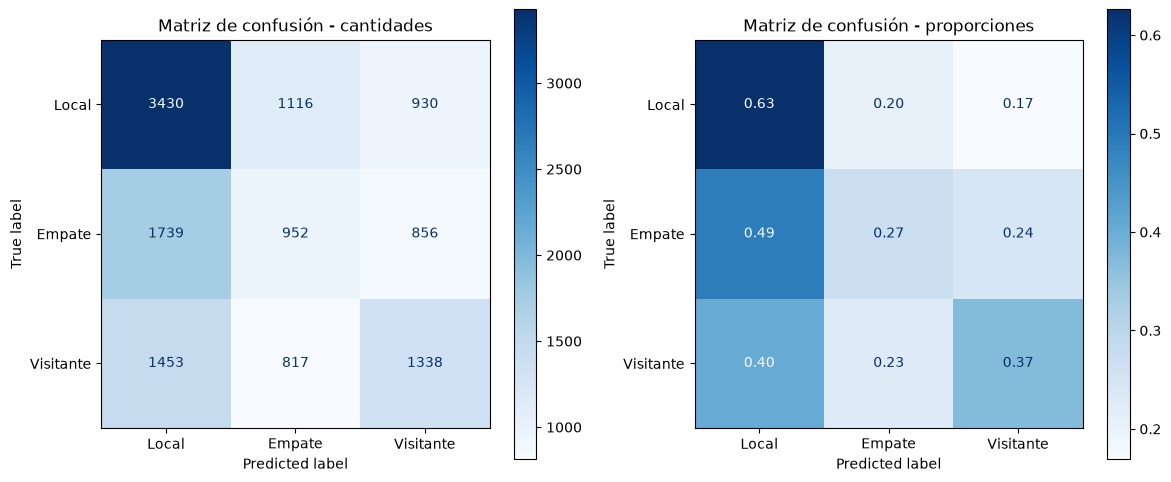

              precision    recall  f1-score   support

       Local       0.52      0.63      0.57      5476
      Empate       0.33      0.27      0.30      3547
   Visitante       0.43      0.37      0.40      3608

    accuracy                           0.45     12631
   macro avg       0.43      0.42      0.42     12631
weighted avg       0.44      0.45      0.44     12631



In [21]:
from sklearn.base import clone
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
)
import matplotlib.pyplot as plt
import numpy as np


real_results = []
predicted_results = []

#volvemos a entrenar el mejor modelo para cada division temporal
for fit_indices, validation_indices in temporal_splits:

    fold_model = clone(
        search.best_estimator_
    )

    fold_model.fit(
        X_train.iloc[fit_indices],
        y_train.iloc[fit_indices],
    )

    fold_predictions = fold_model.predict(
        X_train.iloc[validation_indices]
    )

    real_results.extend(
        y_train.iloc[validation_indices]
    )

    predicted_results.extend(
        fold_predictions
    )


real_results = np.asarray(real_results)
predicted_results = np.asarray(predicted_results)

labels = ["L", "E", "V"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

#cantidad de partidos
ConfusionMatrixDisplay.from_predictions(
    real_results,
    predicted_results,
    labels=labels,
    display_labels=[
        "Local",
        "Empate",
        "Visitante",
    ],
    cmap="Blues",
    values_format="d",
    ax=axes[0],
)

axes[0].set_title(
    "Matriz de confusión - cantidades"
)

#porcentaje correcto dentro de cada clase real
ConfusionMatrixDisplay.from_predictions(
    real_results,
    predicted_results,
    labels=labels,
    display_labels=[
        "Local",
        "Empate",
        "Visitante",
    ],
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    ax=axes[1],
)

axes[1].set_title(
    "Matriz de confusión - proporciones"
)

plt.tight_layout()
plt.show()


print(
    classification_report(
        real_results,
        predicted_results,
        labels=labels,
        target_names=[
            "Local",
            "Empate",
            "Visitante",
        ],
        zero_division=0,
    )
)

## Registro de experimentos
La siguiente celda agrega una fila por ejecucion a `experimentos_tree.csv`, sin borrar el historial. Ejecutar todo el notebook para registrar una nueva corrida. Volver a ejecutar solo esta celda agrega otra fila.
La fila inicial proviene de las salidas guardadas: las metricas conservan la precision mostrada; los datos no disponibles quedan vacios. Las metricas son de validacion temporal, no del test reservado.


In [22]:
# Registro persistente: ejecutar al terminar cada experimento.
import csv
import json
from datetime import datetime, timezone
from pathlib import Path
import load

# Guardamos junto al dataset, independientemente del directorio de ejecucion.
csv_path = Path(load.__file__).resolve().parent / "experimentos_tree.csv"
best_index = search.best_index_
best_parameters = search.best_estimator_.get_params()
parameter_names = [
    "model__min_info_gain",
    "preprocessing__differences__discretizer__record_margin",
    "preprocessing__differences__discretizer__last_matches_margin",
    "preprocessing__differences__discretizer__goal_difference_margin",
    "preprocessing__differences__discretizer__attack_margin",
    "preprocessing__differences__discretizer__defense_margin",
    "preprocessing__draw_rate__discretizer__low_threshold",
    "preprocessing__draw_rate__discretizer__high_threshold",
]
experiment = {
    "fecha_utc": datetime.now(timezone.utc).isoformat(),
    "origen": "ejecucion",
    "validation_years": json.dumps(validation_years),
    "window_years": window_years,
    "n_train": len(X_train),
    "n_test_reservado": len(X_test),
    "param_grid": json.dumps(param_grid, sort_keys=True),
    "mejores_parametros": json.dumps({
        name: best_parameters[name] for name in parameter_names
    }, sort_keys=True),
    "refit": search.refit,
    "cv_accuracy": search.cv_results_["mean_test_accuracy"][best_index],
    "cv_f1_macro": search.cv_results_["mean_test_f1_macro"][best_index],
    "cv_balanced_accuracy": search.cv_results_["mean_test_balanced_accuracy"][best_index],
    "reporte_validacion": classification_report(
        real_results, predicted_results, labels=labels,
        target_names=["Local", "Empate", "Visitante"], zero_division=0,
    ),
    "notas": f"Muestreo directo sin reemplazo; n_iter={candidate_count}; semilla={random_state}",
}
# Mantener una sola linea por experimento en el CSV.
experiment["reporte_validacion"] = " | ".join(
    " ".join(line.split())
    for line in experiment["reporte_validacion"].splitlines() if line.strip()
)
has_header = csv_path.exists() and csv_path.stat().st_size > 0
if has_header:
    with csv_path.open(newline="", encoding="utf-8") as file:
        if next(csv.reader(file)) != list(experiment):
            raise ValueError("El CSV tiene columnas incompatibles; no se modifico.")
with csv_path.open("a", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=experiment)
    if not has_header:
        writer.writeheader()
    writer.writerow(experiment)
print(f"Experimento guardado en {csv_path}")


Experimento guardado en C:\Users\agust\Desktop\Agus\Facultad\2026\2do-semestre\AA\AprendizajeAutomatico\Tarea1\dataset\experimentos_tree.csv
